# DKTC EDA & 전처리
**Dataset of Korean Threatening Conversations**  
5클래스 분류: 협박 대화 / 갈취 대화 / 직장 내 괴롭힘 대화 / 기타 괴롭힘 대화 / 일상 대화

## 0. 라이브러리 및 데이터 로드

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# 클래스명 영문 매핑 (폰트 문제 방지)
label_name_map = {
    '협박 대화': 'Threat',
    '갈취 대화': 'Extortion',
    '직장 내 괴롭힘 대화': 'Workplace',
    '기타 괴롭힘 대화': 'Harassment',
    '일상 대화': 'Normal'
}

# 데이터 로드
train_df  = pd.read_csv('../data/raw/train.csv')
normal_df = pd.read_csv('../data/team_data/PBCC_normal.csv')

print('train shape  :', train_df.shape)
print('normal shape :', normal_df.shape)

train shape  : (3950, 3)
normal shape : (999, 3)


## 1. 데이터 미리보기

In [2]:
print('=== train.csv 상위 3행 ===')
display(train_df.head(3))
print('\n=== 일상대화 상위 3행 ===')
display(normal_df.head(3))

=== train.csv 상위 3행 ===


,idx,class,conversation
0,0,협박 대화,지금 너 스스로를 죽여달라고 애원하는 것인가?\n 아닙니다. 죄송합니다.\n 죽을 ...
1,1,협박 대화,길동경찰서입니다.\n9시 40분 마트에 폭발물을 설치할거다.\n네?\n똑바로 들어 ...
2,2,기타 괴롭힘 대화,너 되게 귀여운거 알지? 나보다 작은 남자는 첨봤어.\n그만해. 니들 놀리는거 재미...



=== 일상대화 상위 3행 ===


,idx,class,conversation
0,3950,일상 대화,오늘 점심에 뭐 먹을지 벌써 고민되는데 추천 좀 해줄래?\n글쎄 어제는 중식 먹었으...
1,3951,일상 대화,너 어제 새로 생긴 마라탕집 가봤어? 국물이 진짜 진하다던데\n응 퇴근하고 갔는데 ...
2,3952,일상 대화,오늘 저녁에 삼겹살에 소주 한잔 어때? 갑자기 기름진 게 땡기네\n삼겹살 좋지 근데...


## 2. 데이터 병합

In [3]:
print('train 컬럼  :', train_df.columns.tolist())
print('일상대화 컬럼:', normal_df.columns.tolist())

df = pd.concat([train_df, normal_df], ignore_index=True)

# 영문 클래스명 컬럼 추가
df['class_en'] = df['class'].map(label_name_map)

print('\n병합 후 shape:', df.shape)
display(df.head(3))
display(df.tail(3))

train 컬럼  : ['idx', 'class', 'conversation']
일상대화 컬럼: ['idx', 'class', 'conversation']

병합 후 shape: (4949, 4)


,idx,class,conversation,class_en
0,0,협박 대화,지금 너 스스로를 죽여달라고 애원하는 것인가?\n 아닙니다. 죄송합니다.\n 죽을 ...,Threat
1,1,협박 대화,길동경찰서입니다.\n9시 40분 마트에 폭발물을 설치할거다.\n네?\n똑바로 들어 ...,Threat
2,2,기타 괴롭힘 대화,너 되게 귀여운거 알지? 나보다 작은 남자는 첨봤어.\n그만해. 니들 놀리는거 재미...,Harassment


,idx,class,conversation,class_en
4946,4946,일상 대화,오늘 아침에 영하 10도까지 떨어졌대 진짜 역대급 한파다 \n 어쩐지 이불 밖으로 ...,Normal
4947,4947,일상 대화,태풍 온다더니 바람 소리가 장난 아니네요 창문 흔들리는 거 봐 \n 저희 동네는 벌...,Normal
4948,4948,일상 대화,오늘 미세먼지 수치 실화냐? 하늘이 뿌옇다 못해 노란색이야 \n 그러게 나 아침에 ...,Normal


## 3. 기본 정보 확인

In [4]:
print('=== 기본 정보 ===')
df.info()
print()
print('=== 결측값 ===')
print(df.isnull().sum())
print()
print('=== 중복 행 수 ===')
print(df.duplicated().sum())

=== 기본 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4949 entries, 0 to 4948
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   idx           4949 non-null   int64 
 1   class         4949 non-null   object
 2   conversation  4949 non-null   object
 3   class_en      4949 non-null   object
dtypes: int64(1), object(3)
memory usage: 154.8+ KB

=== 결측값 ===
idx             0
class           0
conversation    0
class_en        0
dtype: int64

=== 중복 행 수 ===
0


In [5]:
print('=== 클래스 분포 ===')
class_counts = df['class_en'].value_counts()
print(class_counts)
print(f'\n전체 데이터 수: {len(df)}')

=== 클래스 분포 ===
class_en
Harassment    1094
Normal         999
Extortion      981
Workplace      979
Threat         896
Name: count, dtype: int64

전체 데이터 수: 4949


## 4. 클래스 분포 시각화

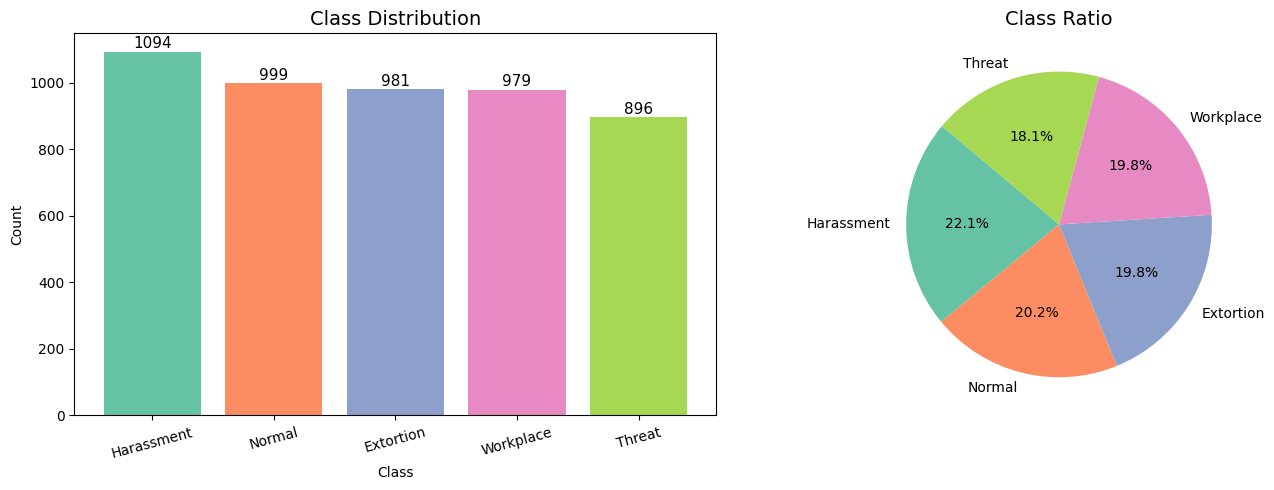

Threat=협박, Extortion=갈취, Workplace=직장내괴롭힘, Harassment=기타괴롭힘, Normal=일상대화
-> 클래스 불균형 여부 확인. 심각한 불균형이 있으면 학습 시 class_weight 적용을 고려합니다.


In [8]:
class_order = df['class_en'].value_counts().index.tolist()
colors = sns.color_palette('Set2', len(class_order))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 막대 그래프
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 10, str(v), ha='center', fontsize=11)

# 파이 차트
axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)
axes[1].set_title('Class Ratio', fontsize=14)

plt.tight_layout()
plt.savefig('../data/image/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Threat=협박, Extortion=갈취, Workplace=직장내괴롭힘, Harassment=기타괴롭힘, Normal=일상대화')
print('-> 클래스 불균형 여부 확인. 심각한 불균형이 있으면 학습 시 class_weight 적용을 고려합니다.')

## 5. 텍스트 길이 분석

In [9]:
df['text_len'] = df['conversation'].str.len()

print('=== 전체 텍스트 길이 통계 ===')
print(df['text_len'].describe().round(1))
print()
print('=== 클래스별 평균 텍스트 길이 ===')
print(df.groupby('class_en')['text_len'].mean().round(1))

=== 전체 텍스트 길이 통계 ===
count    4949.0
mean      240.0
std       116.8
min        41.0
25%       155.0
50%       214.0
75%       294.0
max       874.0
Name: text_len, dtype: float64

=== 클래스별 평균 텍스트 길이 ===
class_en
Extortion     216.2
Harassment    210.1
Normal        292.9
Threat        246.1
Workplace     237.6
Name: text_len, dtype: float64


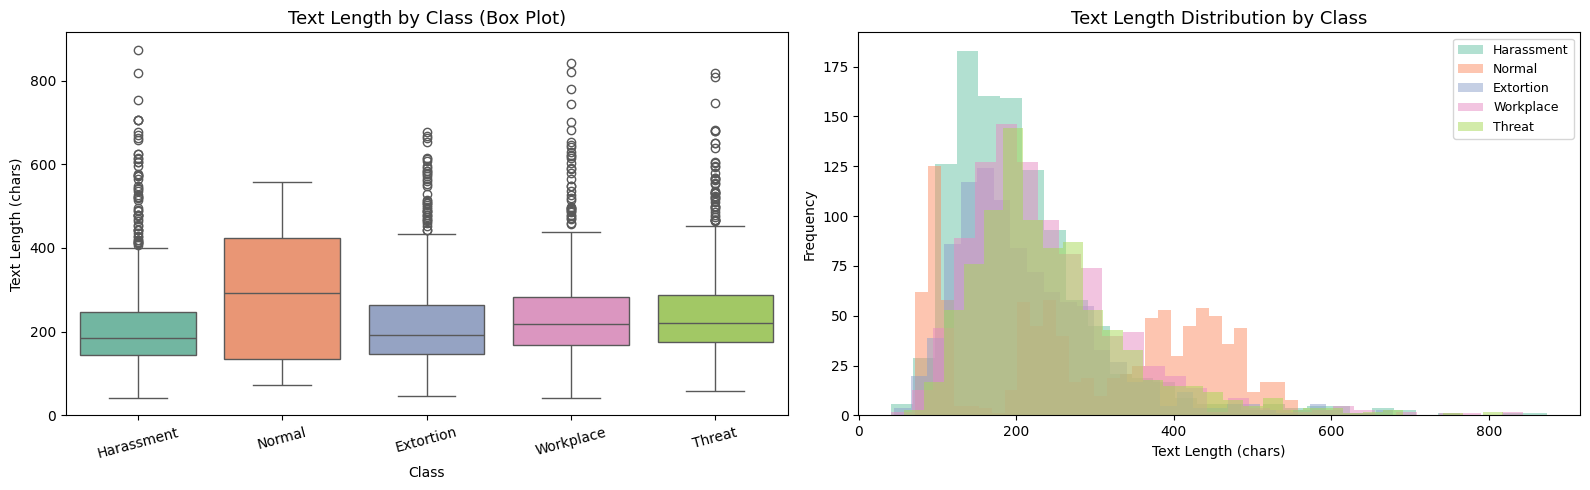

-> 텍스트가 너무 길면 모델의 max_length를 초과할 수 있으니 확인이 필요합니다.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 박스플롯
sns.boxplot(data=df, x='class_en', y='text_len', order=class_order, palette='Set2', ax=axes[0])
axes[0].set_title('Text Length by Class (Box Plot)', fontsize=13)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Text Length (chars)')
axes[0].tick_params(axis='x', rotation=15)

# 히스토그램
for cls, color in zip(class_order, colors):
    subset = df[df['class_en'] == cls]['text_len']
    axes[1].hist(subset, bins=30, alpha=0.5, label=cls, color=color)
axes[1].set_title('Text Length Distribution by Class', fontsize=13)
axes[1].set_xlabel('Text Length (chars)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/image/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('-> 텍스트가 너무 길면 모델의 max_length를 초과할 수 있으니 확인이 필요합니다.')

## 6. 턴(Turn) 수 분석

In [13]:
df['turn_count'] = df['conversation'].str.split('\n').apply(
    lambda x: len([t for t in x if t.strip() != ''])
)

print('=== 전체 턴 수 통계 ===')
print(df['turn_count'].describe().round(2))
print()
print('=== 클래스별 평균 턴 수 ===')
print(df.groupby('class_en')['turn_count'].mean().round(2))

=== 전체 턴 수 통계 ===
count    4949.00
mean        8.46
std         3.90
min         1.00
25%         9.00
50%        10.00
75%        10.00
max        25.00
Name: turn_count, dtype: float64

=== 클래스별 평균 턴 수 ===
class_en
Extortion     10.49
Harassment    10.20
Normal         1.00
Threat        10.34
Workplace     10.38
Name: turn_count, dtype: float64


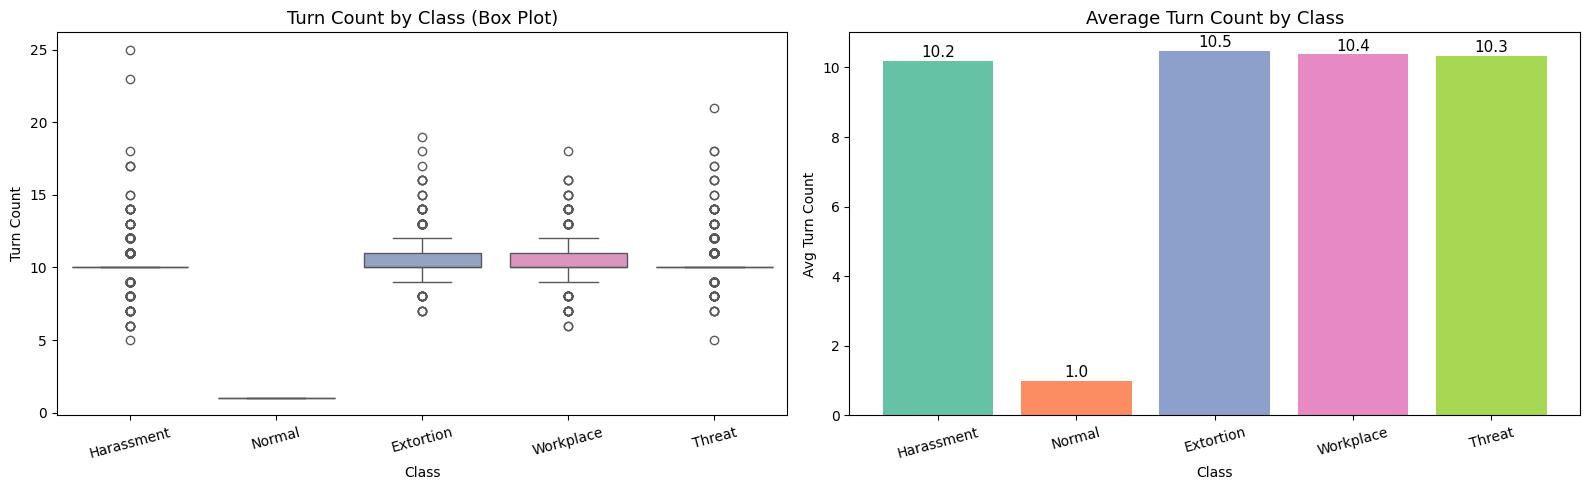

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 박스플롯
sns.boxplot(data=df, x='class_en', y='turn_count', order=class_order, palette='Set2', ax=axes[0])
axes[0].set_title('Turn Count by Class (Box Plot)', fontsize=13)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Turn Count')
axes[0].tick_params(axis='x', rotation=15)

# 평균 막대 그래프
mean_turns = df.groupby('class_en')['turn_count'].mean().reindex(class_order)
bars = axes[1].bar(mean_turns.index, mean_turns.values, color=colors)
axes[1].set_title('Average Turn Count by Class', fontsize=13)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Avg Turn Count')
axes[1].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, mean_turns.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.1, f'{v:.1f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../data/image/turn_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 전처리

In [23]:
def preprocess_conversation(text):
    """
    대화 텍스트 전처리 함수 ([sep] 토큰 적용)
    1. 줄 단위 분리 및 각 줄 앞뒤 공백 제거
    2. 내용이 있는 줄만 필터링
    3. 각 줄을 [sep] 토큰으로 연결
    4. 연속된 공백 하나로 정리
    """
    if pd.isna(text):
        return text
    
    # 0. 문자열 형태의 \\n을 실제 줄바꿈 \n으로 먼저 변환 (추가된 단계)
    text = text.replace('\\n', '\n')

    # 1. 줄 단위 분리 및 앞뒤 공백 제거
    lines = text.split('\n')
    lines = [line.strip() for line in lines]
    
    # 2. 빈 줄 제거
    lines = [line for line in lines if line != '']
    
    # 3. [SEP] 토큰으로 합치기
    # 앞뒤에 공백을 한 칸씩 두어 토크나이저가 [SEP]를 독립된 토큰으로 잘 인식하게 합니다.
    text = ' [SEP] '.join(lines)
    
    # 4. 연속 공백 정리 및 양끝 공백 제거
    text = re.sub(r' +', ' ', text).strip()
    
    return text

# 적용
df['conversation_clean'] = df['conversation'].apply(preprocess_conversation)

# 확인
print('=== 전처리 전 ===')
print(repr(df['conversation'].iloc[0][:200]))
print(repr(df['conversation'].iloc[4000][:200]))


print('\n=== 전처리 후 ===')
print(repr(df['conversation_clean'].iloc[0][:200]))
print(repr(df['conversation_clean'].iloc[4000][:200]))


=== 전처리 전 ===
'지금 너 스스로를 죽여달라고 애원하는 것인가?\n 아닙니다. 죄송합니다.\n 죽을 거면 혼자 죽지 우리까지 사건에 휘말리게 해? 진짜 죽여버리고 싶게.\n 정말 잘못했습니다.\n 너가 선택해. 너가 죽을래 네 가족을 죽여줄까.\n 죄송합니다. 정말 잘못했습니다.\n 너에게는 선택권이 없어. 선택 못한다면 너와 네 가족까지 모조리 죽여버릴거야.\n 선택 못하겠습니다. 한'
'너 이번에 넷플릭스에 새로 올라온 시리즈 봤어? 진짜 재밌더라\\n아 그 SF 장르 말하는 거지? 나도 주말에 1화 봤는데 몰입감 대박이야\\n맞아 나도 처음에 한 편만 보려다가 결국 앉은 자리에서 완결까지 다 봤어\\n벌써 다 봤다고? 총 8부작인데 그걸 하루 만에 다 보다니 대단하다\\n중간에 끊을 수가 없더라고 반전에 반전이 계속돼서 눈을 뗄 수가 없어\\n나'

=== 전처리 후 ===
'지금 너 스스로를 죽여달라고 애원하는 것인가? [SEP] 아닙니다. 죄송합니다. [SEP] 죽을 거면 혼자 죽지 우리까지 사건에 휘말리게 해? 진짜 죽여버리고 싶게. [SEP] 정말 잘못했습니다. [SEP] 너가 선택해. 너가 죽을래 네 가족을 죽여줄까. [SEP] 죄송합니다. 정말 잘못했습니다. [SEP] 너에게는 선택권이 없어. 선택 못한다면 너와 네 '
'너 이번에 넷플릭스에 새로 올라온 시리즈 봤어? 진짜 재밌더라 [SEP] 아 그 SF 장르 말하는 거지? 나도 주말에 1화 봤는데 몰입감 대박이야 [SEP] 맞아 나도 처음에 한 편만 보려다가 결국 앉은 자리에서 완결까지 다 봤어 [SEP] 벌써 다 봤다고? 총 8부작인데 그걸 하루 만에 다 보다니 대단하다 [SEP] 중간에 끊을 수가 없더라고 반전에 반전'


In [24]:
# 클래스 레이블 숫자 변환
label_map = {
    '협박 대화': 0,
    '갈취 대화': 1,
    '직장 내 괴롭힘 대화': 2,
    '기타 괴롭힘 대화': 3,
    '일상 대화': 4
}

df['label'] = df['class'].map(label_map)

print('=== 레이블 매핑 결과 ===')
print(df[['class', 'class_en', 'label']].drop_duplicates().sort_values('label'))
print()
print('=== 결측 레이블 확인 (0이면 정상) ===')
print(df['label'].isnull().sum())

=== 레이블 매핑 결과 ===
            class    class_en  label
0           협박 대화      Threat      0
3           갈취 대화   Extortion      1
5     직장 내 괴롭힘 대화   Workplace      2
2       기타 괴롭힘 대화  Harassment      3
3950        일상 대화      Normal      4

=== 결측 레이블 확인 (0이면 정상) ===
0


## 8. 전처리 후 텍스트 길이 변화 확인

=== 전처리 전후 클래스별 평균 텍스트 길이 비교 ===
            Before  After
class_en                 
Extortion    216.2  271.1
Harassment   210.1  263.4
Normal       292.9  332.7
Threat       246.1  299.9
Workplace    237.6  291.9


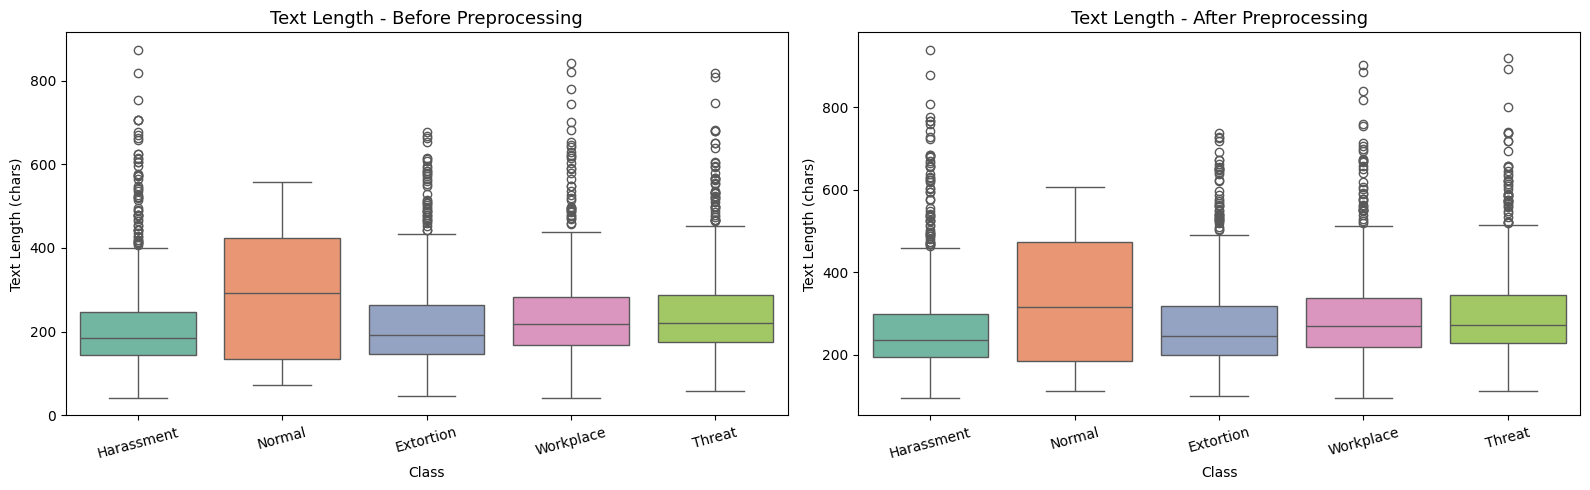

In [28]:
df['text_len_clean'] = df['conversation_clean'].str.len()

print('=== 전처리 전후 클래스별 평균 텍스트 길이 비교 ===')
comparison = df.groupby('class_en')[['text_len', 'text_len_clean']].mean().round(1)
comparison.columns = ['Before', 'After']
print(comparison)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x='class_en', y='text_len', order=class_order, palette='Set2', ax=axes[0])
axes[0].set_title('Text Length - Before Preprocessing', fontsize=13)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Text Length (chars)')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df, x='class_en', y='text_len_clean', order=class_order, palette='Set2', ax=axes[1])
axes[1].set_title('Text Length - After Preprocessing', fontsize=13)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Text Length (chars)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../data/image/text_length_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 최종 데이터 확인 및 저장

In [29]:
final_df = df[['idx', 'class', 'label', 'conversation_clean']].copy()
final_df = final_df.rename(columns={'conversation_clean': 'conversation'})

print('=== 최종 데이터 shape ===')
print(final_df.shape)
print()
print('=== 클래스별 최종 데이터 수 ===')
print(final_df['class'].value_counts())
print()
display(final_df.head())
display(final_df.tail())
# 저장
final_save_path = "../data/processed/train_processed.csv"

final_df.to_csv(final_save_path, index=False)
print('\n 저장 완료')

=== 최종 데이터 shape ===
(4949, 4)

=== 클래스별 최종 데이터 수 ===
class
기타 괴롭힘 대화      1094
일상 대화           999
갈취 대화           981
직장 내 괴롭힘 대화     979
협박 대화           896
Name: count, dtype: int64



,idx,class,label,conversation
0,0,협박 대화,0,지금 너 스스로를 죽여달라고 애원하는 것인가? [SEP] 아닙니다. 죄송합니다. [...
1,1,협박 대화,0,길동경찰서입니다. [SEP] 9시 40분 마트에 폭발물을 설치할거다. [SEP] 네...
2,2,기타 괴롭힘 대화,3,너 되게 귀여운거 알지? 나보다 작은 남자는 첨봤어. [SEP] 그만해. 니들 놀리...
3,3,갈취 대화,1,어이 거기 [SEP] 예?? [SEP] 너 말이야 너. 이리 오라고 [SEP] 무슨...
4,4,갈취 대화,1,저기요 혹시 날이 너무 뜨겁잖아요? 저희 회사에서 이 선크림 파는데 한 번 손등에 ...


,idx,class,label,conversation
4944,4944,일상 대화,4,오늘 날씨 진짜 완연한 봄이네요! 길가에 개나리도 폈더라고요 [SEP] 오 진짜요?...
4945,4945,일상 대화,4,와 갑자기 비가 너무 쏟아지는데? 하늘에 구멍 뚫린 줄 알았어 [SEP] 방금 전까...
4946,4946,일상 대화,4,오늘 아침에 영하 10도까지 떨어졌대 진짜 역대급 한파다 [SEP] 어쩐지 이불 밖...
4947,4947,일상 대화,4,태풍 온다더니 바람 소리가 장난 아니네요 창문 흔들리는 거 봐 [SEP] 저희 동네...
4948,4948,일상 대화,4,오늘 미세먼지 수치 실화냐? 하늘이 뿌옇다 못해 노란색이야 [SEP] 그러게 나 아...



 저장 완료
